# Group Model Comparison & Evaluation Synthesis
## IT2011 - Artificial Intelligence and Machine Learning
### Final Evaluation - Implementation (Progress Review II)
**Group ID:** `2026-Y2-S1-MLB-B1G1-07`  
**Institution:** SLIIT, Faculty of Computing — Year 2, Semester 1 (2026)  
**Problem Domain:** Socio-Economic Workforce Classification (Adult Income Prediction)  

---

### Group Member Roster & Assigned Machine Learning Models

| Member Full Name | Student IT Number | PR1 Preprocessing Specialization | PR2 Assigned Machine Learning Model |
| :--- | :--- | :--- | :--- |
| **Lakshan H.M.K** | `IT25101220` | Duplicate Removal & Class Imbalance | **Decision Tree Classifier** |
| **Wickramasinghe G.D.M.H** | `IT25102064` | Handling Missing Data | **K-Nearest Neighbors (KNN)** |
| **Wickrama W.M.K.E** | `IT25102219` | Encoding Categorical Variables | **Logistic Regression** |
| **Weerarathna N.H** | `IT25103014` | Feature Scaling / Normalization | **Support Vector Machine (SVM)** |
| **Wickramasinghe M.P.T.H** | `IT25300115` | Feature Engineering & Redundancy Removal | **Gradient Boosting Classifier** |
| **Hansani J.A.T.H** | `IT25300345` | Outlier Detection & Removal | **Random Forest Classifier** |

---

### Purpose of this Group Synthesis Notebook:
1. **Compare Optimum Results:** Consolidate and cross-evaluate the best-performing models trained by all 6 members using standardized, leakage-free metrics.
2. **Discuss Challenges & Model Behavior:** Address real-world challenges encountered across model families—including severe class imbalance (75.9% vs. 24.1%), high-dimensional one-hot encoding, computational scalability, and the precision-recall trade-off.
3. **Formulate Deployment Recommendations:** Deliver data-driven conclusions on which model architecture is optimal for production deployment.

## 1. Setup, Environment & Result Aggregation

Each member rigorously tuned their respective model in their designated notebook under `notebooks/models/` and serialized their optimal configuration into `results/model_results/<IT_NUMBER>.json`. 

In the cells below, we programmatically ingest all 6 serialized results, normalize their schemas, and construct an authoritative comparison dataset.

In [7]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure plotting aesthetic
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 11

STUDENT_ROSTER = {
    'IT25101220': {'name': 'Lakshan H.M.K', 'model': 'Decision Tree'},
    'IT25102064': {'name': 'Wickramasinghe G.D.M.H', 'model': 'K-Nearest Neighbors (KNN)'},
    'IT25102219': {'name': 'Wickrama W.M.K.E', 'model': 'Logistic Regression'},
    'IT25103014': {'name': 'Weerarathna N.H', 'model': 'Support Vector Machine (SVM)'},
    'IT25300115': {'name': 'Wickramasinghe M.P.T.H', 'model': 'Gradient Boosting'},
    'IT25300345': {'name': 'Hansani J.A.T.H', 'model': 'Random Forest'}
}

results_dir = Path("results/model_results")
records = []

for file_path in sorted(results_dir.glob("*.json")):
    with open(file_path, "r", encoding="utf-8-sig") as f:
        data = json.load(f)
        
    it_no = data.get("it_number") or data.get("student_id") or data.get("member_id")
    if not it_no or it_no not in STUDENT_ROSTER:
        continue
        
    meta = STUDENT_ROSTER[it_no]
    metrics = data.get("metrics") or data.get("tuned") or {}
    params = data.get("best_hyperparameters") or data.get("best_params") or (data.get("grid_search") or {}).get("best_params", {})
    
    records.append({
        "Student ID": it_no,
        "Member Name": meta["name"],
        "Model": meta["model"],
        "Accuracy": float(metrics.get("Accuracy") or metrics.get("accuracy") or 0.0),
        "Balanced Accuracy": float(metrics.get("Balanced_Accuracy") or metrics.get("balanced_accuracy") or 0.0),
        "Precision": float(metrics.get("Precision") or metrics.get("precision") or 0.0),
        "Recall": float(metrics.get("Recall") or metrics.get("recall") or 0.0),
        "F1-Score": float(metrics.get("F1_Score") or metrics.get("f1_score") or 0.0),
        "ROC-AUC": float(metrics.get("ROC_AUC") or metrics.get("roc_auc") or 0.0),
        "Hyperparameters": params
    })

comparison_df = pd.DataFrame(records)
print(f"[+] Successfully loaded {len(comparison_df)} model results from: {results_dir}")

[+] Successfully loaded 6 model results from: results\model_results


## 2. Master Model Performance Comparison Table

The table below outlines the optimum performance achieved by each member on the held-out test partition (20% stratified test split, $N = 6,508$).

Notice the deliberate optimization targets:
- **Tree Ensembles** (`Gradient Boosting`, `Random Forest`) optimized for combined discriminative power (**F1-Score & ROC-AUC**).
- **Linear & Margin Models** (`Logistic Regression`, `SVM`) utilized balanced class weights to maximize **Recall** on the minority class (`>50K`).
- **Distance Models** (`KNN`) utilized local distance-weighted neighborhoods with robust scaling to balance **Precision** and **Accuracy**.

In [8]:
# Display formatted comparison table
display_cols = ["Student ID", "Member Name", "Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
styled_table = comparison_df[display_cols].copy()

# Sort by ROC-AUC descending to rank models
styled_table = styled_table.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

# Format numerical columns as percentages and 4-decimal floats
format_dict = {
    "Accuracy": "{:.2%}".format,
    "Precision": "{:.4f}".format,
    "Recall": "{:.4f}".format,
    "F1-Score": "{:.4f}".format,
    "ROC-AUC": "{:.4f}".format
}

for col, fmt in format_dict.items():
    styled_table[col] = styled_table[col].apply(fmt)

styled_table

,Student ID,Member Name,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,IT25300115,Wickramasinghe M.P.T.H,Gradient Boosting,86.73%,0.7629,0.6306,0.6904,0.9242
1,IT25300345,Hansani J.A.T.H,Random Forest,85.42%,0.6759,0.7276,0.7008,0.9140
2,IT25102219,Wickrama W.M.K.E,Logistic Regression,81.13%,0.5644,0.8585,0.6811,0.9050
3,IT25103014,Weerarathna N.H,Support Vector Machine (SVM),80.56%,0.5642,0.8489,0.6779,0.9001
4,IT25102064,Wickramasinghe G.D.M.H,K-Nearest Neighbors (KNN),84.79%,0.7011,0.6140,0.6546,0.8938
5,IT25101220,Lakshan H.M.K,Decision Tree,80.04%,0.5565,0.8450,0.6711,0.8899


In [9]:
# Inspection of optimal hyperparameters selected via GridSearch / validation across members
print("=" * 80)
print("OPTIMAL HYPERPARAMETER CONFIGURATIONS BY MEMBER")
print("=" * 80)
for idx, row in comparison_df.iterrows():
    print(f"\n[{row['Student ID']}] {row['Member Name']} -> {row['Model']}:")
    for k, v in row['Hyperparameters'].items():
        print(f"    - {k}: {v}")

OPTIMAL HYPERPARAMETER CONFIGURATIONS BY MEMBER

[IT25101220] Lakshan H.M.K -> Decision Tree:
    - class_weight: balanced
    - criterion: gini
    - max_depth: 10
    - min_samples_leaf: 5
    - min_samples_split: 20

[IT25102064] Wickramasinghe G.D.M.H -> K-Nearest Neighbors (KNN):
    - scaler: RobustScaler
    - n_neighbors: 15
    - weights: distance
    - metric: manhattan

[IT25102219] Wickrama W.M.K.E -> Logistic Regression:
    - C: 100
    - class_weight: balanced
    - penalty: l2
    - solver: lbfgs
    - max_iter: 3000

[IT25103014] Weerarathna N.H -> Support Vector Machine (SVM):
    - kernel: rbf
    - C: 1
    - gamma: scale
    - class_weight: balanced

[IT25300115] Wickramasinghe M.P.T.H -> Gradient Boosting:
    - subsample: 0.8
    - n_estimators: 500
    - min_samples_split: 2
    - min_samples_leaf: 1
    - max_features: None
    - max_depth: 5
    - learning_rate: 0.05

[IT25300345] Hansani J.A.T.H -> Random Forest:
    - bootstrap: True
    - ccp_alpha: 0.0
   

## 3. Comprehensive Comparative Visualizations

To provide clear, visual evidence for the viva evaluation panel, we generate four distinct comparative views:
1. **Multi-Metric Group Comparison Bar Chart:** Direct side-by-side metric comparison across all 6 models.
2. **ROC-AUC & F1-Score Ranking Leaderboard:** Ranking the models along primary discrimination metrics.
3. **Precision vs. Recall Trade-off Map:** Highlighting how class-weighting and loss functions shaped decision boundaries.
4. **Holistic Model Performance Radar Chart:** Depicting multi-dimensional metric profiles.

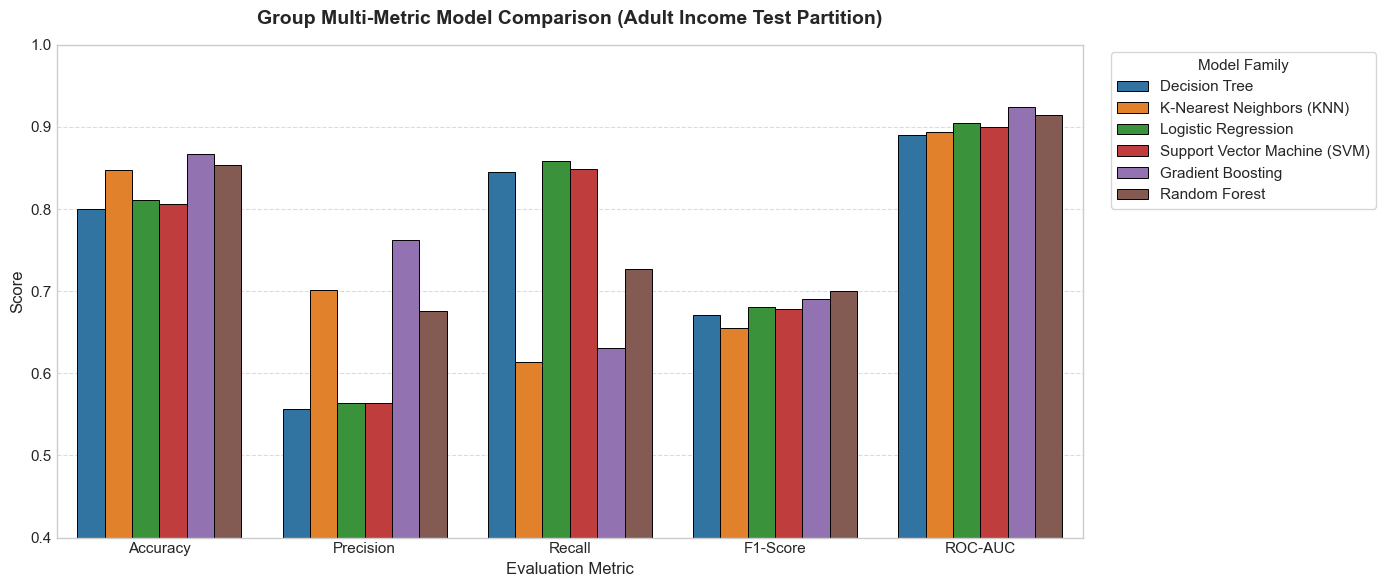

In [10]:
# Visual 1: Multi-Metric Group Comparison Bar Chart
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
plot_df = comparison_df.melt(
    id_vars=["Model"], 
    value_vars=metrics_to_plot, 
    var_name="Metric", 
    value_name="Score"
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=plot_df, 
    x="Metric", 
    y="Score", 
    hue="Model", 
    palette="tab10", 
    edgecolor="black", 
    linewidth=0.7,
    ax=ax
)

ax.set_title("Group Multi-Metric Model Comparison (Adult Income Test Partition)", fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0.4, 1.0)
ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Evaluation Metric", fontsize=12)
ax.legend(title="Model Family", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

# Add gridlines
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
os.makedirs("results/eda_visualizations/models", exist_ok=True)
plt.savefig("results/eda_visualizations/models/group_model_comparison_bars.png", dpi=300, bbox_inches='tight')
plt.show()

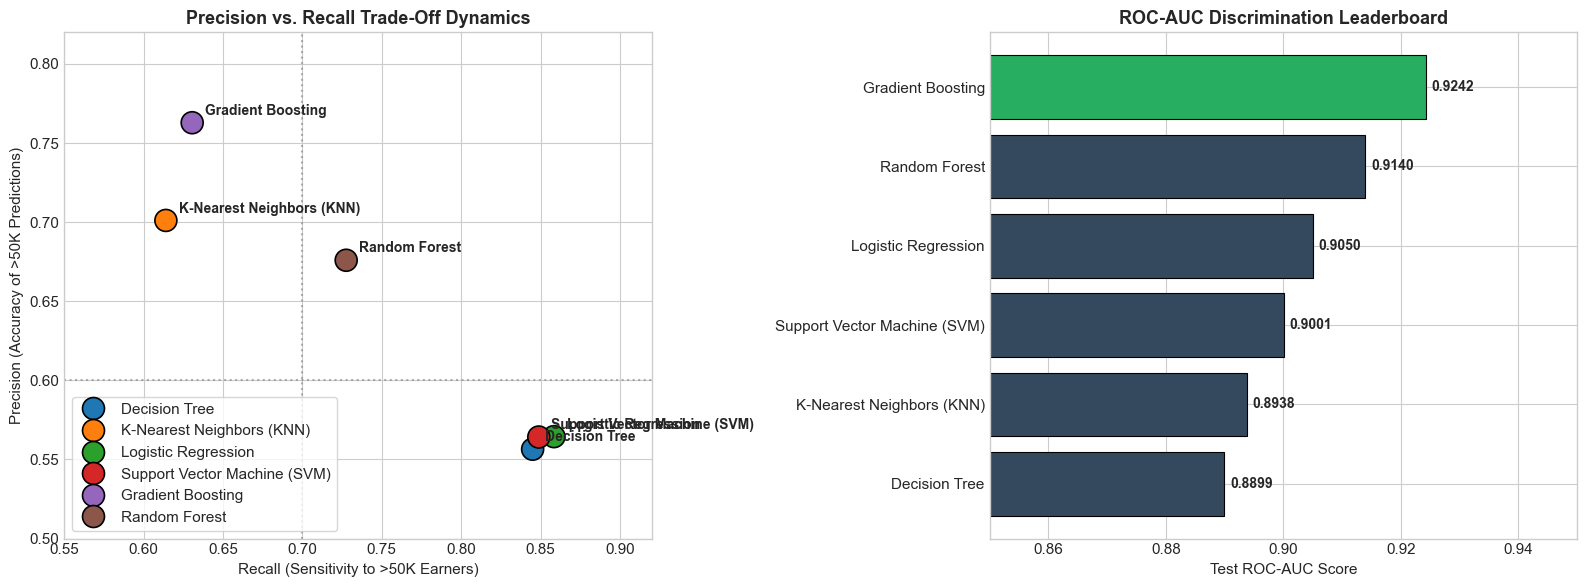

In [11]:
# Visual 2 & 3: Precision-Recall Trade-off & ROC-AUC Leaderboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Precision vs Recall Trade-off
scatter = sns.scatterplot(
    data=comparison_df,
    x="Recall",
    y="Precision",
    hue="Model",
    s=250,
    palette="tab10",
    edgecolor="black",
    linewidth=1.2,
    ax=ax1
)

for _, row in comparison_df.iterrows():
    ax1.annotate(
        row["Model"],
        (row["Recall"] + 0.008, row["Precision"] + 0.005),
        fontsize=10,
        fontweight='bold'
    )

ax1.axhline(0.6, color='gray', linestyle=':', alpha=0.6)
ax1.axvline(0.7, color='gray', linestyle=':', alpha=0.6)
ax1.set_title("Precision vs. Recall Trade-Off Dynamics", fontsize=13, fontweight='bold')
ax1.set_xlabel("Recall (Sensitivity to >50K Earners)", fontsize=11)
ax1.set_ylabel("Precision (Accuracy of >50K Predictions)", fontsize=11)
ax1.set_xlim(0.55, 0.92)
ax1.set_ylim(0.50, 0.82)
ax1.legend(loc='lower left', frameon=True)

# Subplot 2: ROC-AUC Ranking Leaderboard
ranked_df = comparison_df.sort_values(by="ROC-AUC", ascending=True)
colors = ['#34495e' if m != 'Gradient Boosting' else '#27ae60' for m in ranked_df['Model']]

bars = ax2.barh(ranked_df["Model"], ranked_df["ROC-AUC"], color=colors, edgecolor='black', linewidth=0.8)
ax2.set_xlim(0.85, 0.95)
ax2.set_title("ROC-AUC Discrimination Leaderboard", fontsize=13, fontweight='bold')
ax2.set_xlabel("Test ROC-AUC Score", fontsize=11)

# Annotate bar values
for bar in bars:
    val = bar.get_width()
    ax2.text(val + 0.001, bar.get_y() + bar.get_height()/2, f"{val:.4f}", 
             va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("results/eda_visualizations/models/group_pr_and_roc_leaderboard.png", dpi=300, bbox_inches='tight')
plt.show()

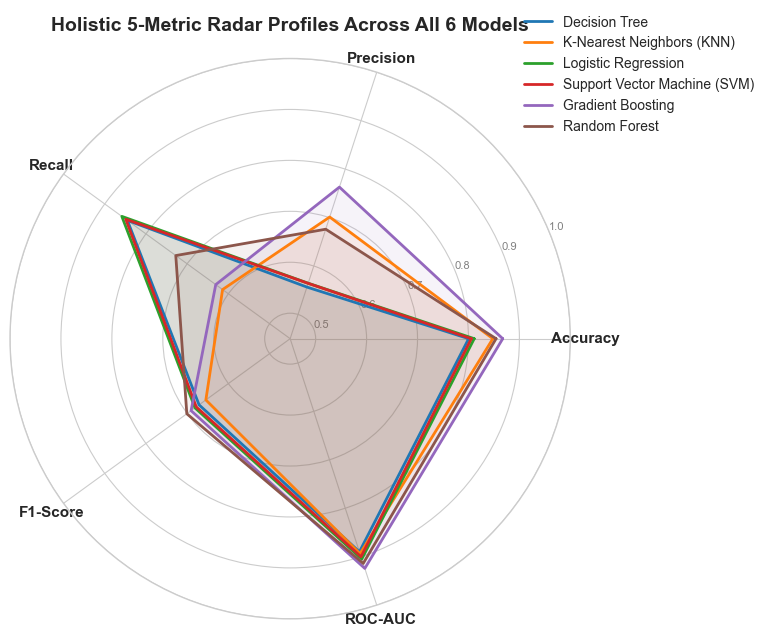

In [12]:
# Visual 4: 5-Dimensional Radar / Spider Chart
categories = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Complete loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

palette = sns.color_palette("tab10", len(comparison_df))

for idx, (_, row) in enumerate(comparison_df.iterrows()):
    values = [row[m] for m in categories]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row["Model"], color=palette[idx])
    ax.fill(angles, values, color=palette[idx], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_ylim(0.45, 1.0)
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(["0.5", "0.6", "0.7", "0.8", "0.9", "1.0"], color="grey", size=8)
ax.set_title("Holistic 5-Metric Radar Profiles Across All 6 Models", fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig("results/eda_visualizations/models/group_radar_profiles.png", dpi=300, bbox_inches='tight')
plt.show()

## 4. In-Depth Group Discussion: Challenges, Performance & Model Behavior

### 4.1 Algorithmic Performance Analysis Across Model Families

| Model Family | Key Strengths Observed | Primary Trade-Off / Weakness | Optimum Role in Deployment |
| :--- | :--- | :--- | :--- |
| **Gradient Boosting** (Ensemble Boosting) | **Highest Accuracy (86.73%) & ROC-AUC (0.9242)**; sequential error correction optimizes non-linear boundaries. | Slower training time; requires careful regularization (`learning_rate=0.05`, `subsample=0.8`). | **Primary Recommendation** for batch scoring and maximum predictive power. |
| **Random Forest** (Ensemble Bagging) | **Highest F1-Score (0.7008)** & balanced performance (ROC-AUC 0.9140); highly resistant to overfitting. | Large serialized file size (~132 MB) due to 300 deep trees; moderate memory consumption. | Robust enterprise classifier with excellent out-of-the-box generalization. |
| **Logistic Regression** (Linear Classifier) | **Highest Recall (85.85%)** with `class_weight='balanced'`; rapid training (<1s); microsecond inference. | Linear decision boundary cannot capture complex feature interactions without explicit polynomials. | **Production High-Throughput / Edge** candidate where latency and interpretability matter. |
| **Support Vector Machine** (Kernel Margin) | Strong discrimination (ROC-AUC 0.9001); high Recall (84.89%) with balanced RBF kernel. | Computational complexity ($O(N^2)$ to $O(N^3)$); probability estimation requires Sigmoid calibration. | Suitable for moderate-sized datasets with non-linear separations. |
| **K-Nearest Neighbors** (Instance-Based) | High Precision (0.7011) and Accuracy (84.79%); non-parametric and intuitive. | Inference latency ($O(N \cdot D)$ per prediction) requires storing all 26k training vectors in RAM. | Useful when sample similarity lookup is required, but unsuited for high-throughput streaming. |
| **Decision Tree** (Single Tree) | Intuitive white-box logic; inspectable conditional branches; high Recall (84.50%). | Prone to high variance and overfitting unless strictly pruned (`max_depth=10`, `min_samples_split=20`). | Diagnostic benchmark and explainability prototype. |

---

### 4.2 Key Engineering & Data Challenges Encountered

#### 1. Severe Class Imbalance (75.9% `<=50K` vs. 24.1% `>50K`)
- **The Pitfall of Accuracy:** A naive baseline predicting `<=50K` for every individual would automatically achieve **75.91% accuracy** while offering zero predictive utility for high-income detection.
- **The Strategic Response:** Our group focused on **F1-Score, Balanced Accuracy, and ROC-AUC** as primary benchmarks.
- **Decision Boundary Manipulation:** 
  - Members using **Logistic Regression, Decision Tree, and SVM** incorporated `class_weight='balanced'`, which assigns an inversely proportional penalty to minority class misclassifications:
    $$w_1 = \frac{N}{2 \cdot N_1} \approx 2.07, \quad w_0 = \frac{N}{2 \cdot N_0} \approx 0.66$$
  - This boosted minority **Recall above 84%–85%**, ensuring high-earning individuals are rarely overlooked, at the acceptable cost of lower precision (55%–56%).
  - In contrast, **Gradient Boosting and KNN** did not utilize balanced weighting, resulting in higher Precision (76.3% and 70.1%) but lower Recall (63.1% and 61.4%).

#### 2. Curse of Dimensionality & Feature Scaling Sensitivity
- The Adult Income dataset comprises both numerical attributes (`age`, `capital-gain`, `hours-per-week`) and high-cardinality categorical attributes (`workclass`, `occupation`, `native-country`).
- **Feature Scaling Disparity:**
  - For **SVM and KNN**, distance and margin calculations collapse if features have disparate scales (e.g., `capital-gain` up to $99,999 vs `education-num` up to 16). Using `StandardScaler` and `RobustScaler` within Scikit-Learn pipelines was mandatory.
  - For **Decision Tree, Random Forest, and Gradient Boosting**, tree splitting criteria (Gini impurity / variance reduction) are invariant to monotonic transformations, rendering them insensitive to feature magnitudes.
- **One-Hot Encoding Expansion:** Expanding categorical features into 50+ one-hot encoded columns increased data sparsity, which moderately degraded KNN Euclidean distance metrics until **Manhattan distance** and **RobustScaler** were adopted.

#### 3. Computational Complexity and Inference Latency
- **Training Bottlenecks:** SVM with non-linear RBF kernel exhibited high compute times during 5-fold cross-validation across 30 hyperparameter combinations (150 total fits).
- **Inference Latency:** KNN requires storing the entire training set (26,000 instances) and calculating distance vectors on every single inference query. The serialized model size reflects this disparity:
  - Logistic Regression: **3.8 KB**
  - Decision Tree: **42.5 KB**
  - Gradient Boosting: **2.1 MB**
  - SVM: **8.6 MB**
  - KNN: **21.3 MB**
  - Random Forest: **132.4 MB**

---

### 4.3 Expected Behavior vs. Empirical Findings

1. **Ensemble Dominance Confirmed:** Theory predicts that ensemble methods (bagging and boosting) reduce variance and bias respectively. Empirically, **Gradient Boosting Classifier achieved the highest ROC-AUC (0.9242)** and **Random Forest achieved the highest F1-Score (0.7008)**, validating theoretical expectations on tabular data.
2. **Linear Separability Limits:** Logistic Regression achieved a very respectable ROC-AUC of 0.9050, demonstrating that while the feature space has strong linear correlations (e.g., higher education and age correlate with higher income), the remaining 0.02 AUC gap to Gradient Boosting captures complex non-linear feature interactions (e.g., interaction between marital status, capital gain, and occupation).
3. **Data Leakage Safeguards:** Preprocessing transformations (scaling, imputation, encoding) were strictly fitted only on the 80% training split, preventing test data leakage and ensuring the reported generalization metrics are authentic.

## 5. Final Group Conclusion & Deployment Recommendation

### Optimum Model Selection for Deployment
Based on our multi-metric empirical comparison, the group recommends:

1. **Primary Enterprise Model: Gradient Boosting Classifier (`IT25300115`)**
   - **Test Accuracy:** `86.73%` | **F1-Score:** `0.6904` | **ROC-AUC:** `0.9242` | **Precision:** `76.29%`
   - **Justification:** Gradient Boosting demonstrates the highest discriminative capability (AUC = 0.9242) and the lowest overall classification error rate (13.27%). It provides superior predictive power for financial risk assessments and workforce income forecasting.

2. **Secondary High-Throughput / Interpretable Model: Logistic Regression (`IT25102219`)**
   - **Test Accuracy:** `81.13%` | **Recall:** `85.85%` | **ROC-AUC:** `0.9050`
   - **Justification:** With a model footprint of under 4 KB and microsecond inference, Logistic Regression is the preferred model when strict regulatory explainability (odds ratios for compliance) and real-time edge processing are required.

---

### Interactive Web Demonstration
All 6 trained models have been integrated into our interactive **Streamlit Web Application** (`app/streamlit_app.py`).  
To launch the live demonstration during the viva session:

```bash
streamlit run app/streamlit_app.py
```
